In [1]:
pip install pandas nltk scikit-learn matplotlib seaborn wordcloud

In [3]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
data = {
    "Review": [
        "The movie was amazing with excellent acting and storyline",
        "Fantastic direction and beautiful music",
        "The film was average and the plot was predictable",
        "The movie was boring and too long",
        "Excellent performances by all actors",
        "The storyline was weak and disappointing",
        "Music was good but the acting was average",
        "An outstanding cinematic experience",
        "Poor direction and bad screenplay",
        "The movie was okay and enjoyable in some parts"
    ],

    "Sentiment": [
        "Positive",
        "Positive",
        "Neutral",
        "Negative",
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Neutral"
    ]
}

df = pd.DataFrame(data)

print(df.head())

                                              Review Sentiment
0  The movie was amazing with excellent acting an...  Positive
1            Fantastic direction and beautiful music  Positive
2  The film was average and the plot was predictable   Neutral
3                  The movie was boring and too long  Negative
4               Excellent performances by all actors  Positive


In [5]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
        and word not in string.punctuation
    ]

    return " ".join(tokens)

df["Cleaned_Review"] = df["Review"].apply(preprocess_text)

print(df[["Review", "Cleaned_Review"]])

                                              Review  \
0  The movie was amazing with excellent acting an...   
1            Fantastic direction and beautiful music   
2  The film was average and the plot was predictable   
3                  The movie was boring and too long   
4               Excellent performances by all actors   
5           The storyline was weak and disappointing   
6          Music was good but the acting was average   
7                An outstanding cinematic experience   
8                  Poor direction and bad screenplay   
9     The movie was okay and enjoyable in some parts   

                             Cleaned_Review  
0  movie amazing excellent acting storyline  
1       fantastic direction beautiful music  
2             film average plot predictable  
3                         movie boring long  
4             excellent performances actors  
5              storyline weak disappointing  
6                 music good acting average  
7          outs

In [6]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Review"])

y = df["Sentiment"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = MultinomialNB()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         1
     Neutral       0.00      0.00      0.00         0
    Positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.33      0.33      0.33         2
weighted avg       0.50      0.50      0.50         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [10]:
positive_reviews = df[df["Sentiment"] == "Positive"]
print("\nPositive Reviews:")
print(positive_reviews["Review"])


Positive Reviews:
0    The movie was amazing with excellent acting an...
1              Fantastic direction and beautiful music
4                 Excellent performances by all actors
7                  An outstanding cinematic experience
Name: Review, dtype: object


In [11]:
negative_reviews = df[df["Sentiment"] == "Negative"]
print("\nNegative Reviews:")
print(negative_reviews["Review"])


Negative Reviews:
3           The movie was boring and too long
5    The storyline was weak and disappointing
8           Poor direction and bad screenplay
Name: Review, dtype: object


In [12]:
neutral_reviews = df[df["Sentiment"] == "Neutral"]
print("\nNeutral Reviews:")
print(neutral_reviews["Review"])


Neutral Reviews:
2    The film was average and the plot was predictable
6            Music was good but the acting was average
9       The movie was okay and enjoyable in some parts
Name: Review, dtype: object


In [13]:
new_reviews = [
    "The acting and music were fantastic",
    "The movie was boring and disappointing",
    "The film was average with decent performances"
]

new_reviews_clean = [preprocess_text(review) for review in new_reviews]

new_vector = vectorizer.transform(new_reviews_clean)

results = model.predict(new_vector)

for review, sentiment in zip(new_reviews, results):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print()

Review: The acting and music were fantastic
Predicted Sentiment: Neutral

Review: The movie was boring and disappointing
Predicted Sentiment: Negative

Review: The film was average with decent performances
Predicted Sentiment: Neutral



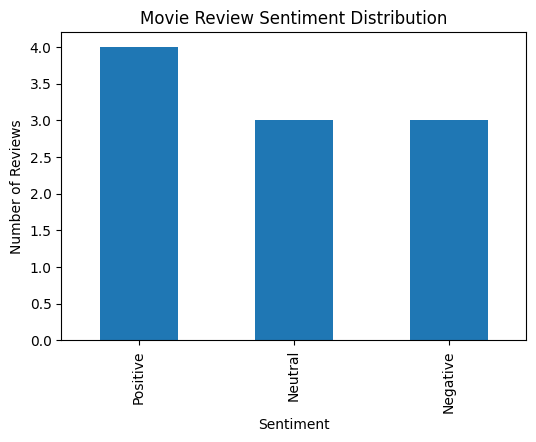

In [14]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')

plt.title("Movie Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

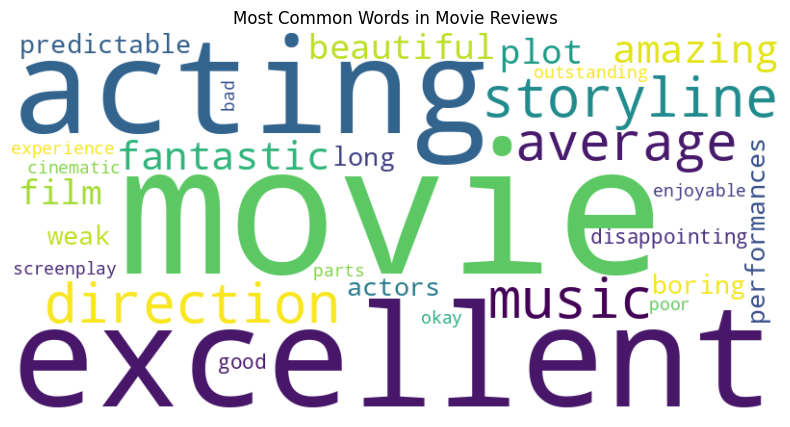

In [15]:
text = " ".join(df["Cleaned_Review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Movie Reviews")
plt.show()